# Predicting UK Workplace Salaries — A Regression Case Study

### From a mean-predictor baseline to a Random Forest, with a focus on business impact and responsible deployment

---

**Author:** Jumma Mohammad Teli — Data Analyst  
📍 Birmingham, UK · 📧 jummamohammad477@gmail.com · 🔗 [LinkedIn](https://linkedin.com/in/jumma-mohammad) · 💻 [GitHub](https://github.com/jumma786)

**Stack:** Python · pandas · scikit-learn · matplotlib  
**Skills demonstrated:** supervised learning, train/test discipline, pipeline construction, model comparison, residual diagnostics, feature importance, business interpretation, AI governance.

---

## Executive summary

A synthetic UK workplace salary dataset (720 employees, 13 features) is used to train and compare four regression approaches — a mean-predictor baseline, ordinary linear regression, Ridge regression, and a Random Forest. The exercise has three goals: demonstrate a defensible end-to-end ML workflow, translate model errors into business impact in £, and show the governance thinking required before any salary model touches a real pay decision.

**Headline result.** Linear regression cuts the average absolute prediction error from **£10,844** (baseline) to **£4,600** — a 58% reduction — and explains **~81%** of the variance in test-set salaries. Ridge regression matches it almost exactly; a Random Forest, somewhat counter-intuitively, underperforms (MAE ≈ £6,600) because the dataset is small and the salary signal is largely linear. Typical predictions land within roughly 7–8% of the actual salary, which is good enough for **workforce planning, budgeting and outlier flagging**, but not for individual pay decisions without human review and a fairness audit.

---

## Contents
1. Business context and problem framing
2. Data loading and quality checks
3. Exploratory data analysis
4. Feature engineering and train/test split
5. Baseline model
6. Linear regression pipeline
7. Model comparison — Ridge and Random Forest
8. Residual diagnostics
9. Feature importance and interpretability
10. Business interpretation
11. Responsible-AI governance caveat
12. Limitations and next steps
13. Reproducibility

## 1. Business context and problem framing

**The brief.** A UK HR analytics team wants a model that can suggest a reasonable salary band given an employee's role, region, experience and skill profile. The intended use is **internal planning** — workforce-cost forecasting, sense-checking job-advert salary bands, and flagging individuals whose pay sits unusually far from peers — not making or replacing individual pay decisions.

**Why this matters.** Salary is a high-stakes, legally sensitive outcome under the UK Equality Act and UK GDPR. A model that quietly bakes in historical inequities can do real harm, so the project is framed deliberately as decision *support*, with a governance section (§11) outlining the controls that must be in place before any deployment.

**Success criteria for this exercise.**
- Beat a mean-predictor baseline on MAE, RMSE and R² by a comfortable margin.
- Express the typical error in **£ and as a % of mean salary** so that a non-technical reader can judge whether the model is fit for planning use.
- Identify which employee profiles the model struggles with, and explain why.
- Document the governance gap between a useful planning model and one safe for real pay decisions.

## 2. Data loading and quality checks

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
    'axes.titleweight': 'bold',
})

RANDOM_STATE = 42
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
DATA_PATH = Path('workplace_salary_regression_dataset.csv')
df = pd.read_csv(DATA_PATH)
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 720   Columns: 15


,employee_record_id,region,role_family,sector,company_size,education_level,seniority_level,years_experience,professional_certifications,technical_skill_score,remote_days_per_week,people_management,weekly_contract_hours,training_hours_last_12m,annual_salary_gbp
0,EMP-0187,North West,Operations,Retail,Medium,Professional certification,Associate,1.90,1,54.20,0,0,34.20,17.30,56000
1,EMP-0497,North West,Software,Education,Large,Professional certification,Associate,3.70,2,93.60,4,0,37.90,66.20,84900
2,EMP-0321,South West,Data,Technology,Medium,Master,Senior,2.10,2,81.50,1,0,40.20,32.00,92900
3,EMP-0363,London,People,Technology,Medium,Bachelor,Mid,6.60,2,77.30,2,0,42.40,61.30,88300
4,EMP-0610,North West,Data,Retail,Enterprise,Professional certification,Associate,8.20,3,77.30,2,0,36.40,44.60,93600


In [3]:
# Data quality snapshot
quality = pd.DataFrame({
    'dtype'        : df.dtypes.astype(str),
    'missing'      : df.isna().sum(),
    'missing_pct'  : (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique(),
})
quality

,dtype,missing,missing_pct,unique_values
employee_record_id,str,0,0.00,720
region,str,0,0.00,8
role_family,str,0,0.00,6
sector,str,0,0.00,6
company_size,str,0,0.00,4
education_level,str,0,0.00,4
seniority_level,str,0,0.00,4
years_experience,float64,0,0.00,146
professional_certifications,int64,0,0.00,7
technical_skill_score,float64,0,0.00,360


**Quality findings.** No missing values across any of the 15 columns and no obviously degenerate features. Cardinality is sensible: the categorical features have between 4 and 12 unique values each, which keeps one-hot encoding manageable. `employee_record_id` is the only column to drop outright — it's an anonymous identifier with no predictive signal.

## 3. Exploratory data analysis

Before modelling, let's understand the shape of the target and the strength of the most plausible drivers.

In [4]:
df['annual_salary_gbp'].describe().round(0)

count       720.00
mean     84,741.00
std      14,056.00
min      47,600.00
25%      74,475.00
50%      83,600.00
75%      93,625.00
max     127,500.00
Name: annual_salary_gbp, dtype: float64

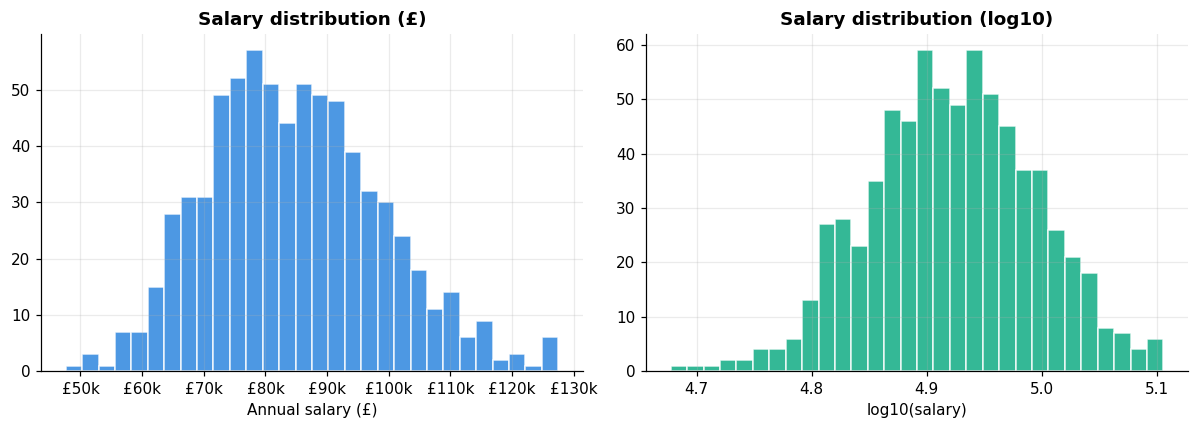

In [5]:
# Target distribution + log distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['annual_salary_gbp'], bins=30, color='#2e86de', edgecolor='white', alpha=0.85)
axes[0].set_title('Salary distribution (£)')
axes[0].set_xlabel('Annual salary (£)')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

axes[1].hist(np.log10(df['annual_salary_gbp']), bins=30, color='#10ac84', edgecolor='white', alpha=0.85)
axes[1].set_title('Salary distribution (log10)')
axes[1].set_xlabel('log10(salary)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Salary is right-skewed but not extremely so — the log transform straightens it out, but it isn't strictly necessary for a linear model on this dataset. We'll keep salary on the original £ scale because **errors expressed in £ are easier to translate to business impact**.

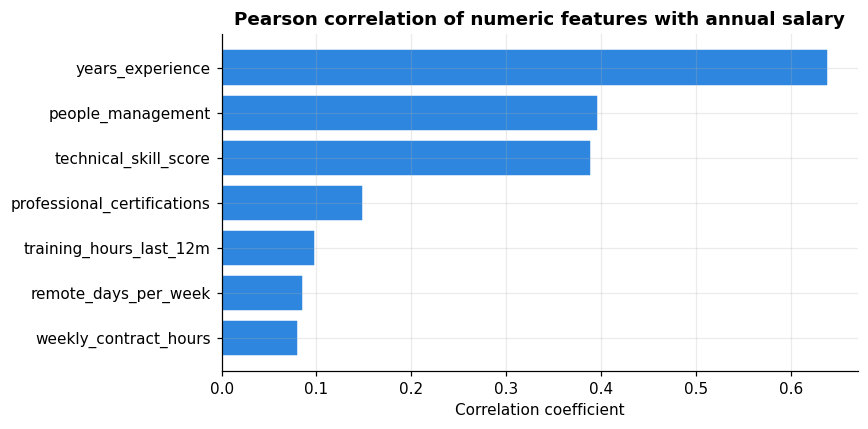

weekly_contract_hours         0.08
remote_days_per_week          0.09
training_hours_last_12m       0.10
professional_certifications   0.15
technical_skill_score         0.39
people_management             0.40
years_experience              0.64
Name: annual_salary_gbp, dtype: float64

In [6]:
# Numeric-feature correlations with the target
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()['annual_salary_gbp'].drop('annual_salary_gbp').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#c0392b' if v < 0 else '#2e86de' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.6)
ax.set_title('Pearson correlation of numeric features with annual salary')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_numeric_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
corr.round(3)

In [7]:
# Median salary by seniority level — categorical signal sanity check
seniority_order = ['Associate', 'Mid', 'Senior', 'Lead']
seniority_present = [s for s in seniority_order if s in df['seniority_level'].unique()]
salary_by_seniority = (
    df.groupby('seniority_level')['annual_salary_gbp']
      .agg(['median', 'mean', 'count'])
      .reindex(seniority_present)
      .round(0)
)
salary_by_seniority

,median,mean,count
seniority_level,,,
Associate,"77,150.00","78,706.00",254
Mid,"83,600.00","84,476.00",261
Senior,"90,650.00","91,346.00",154
Lead,"96,300.00","96,214.00",51


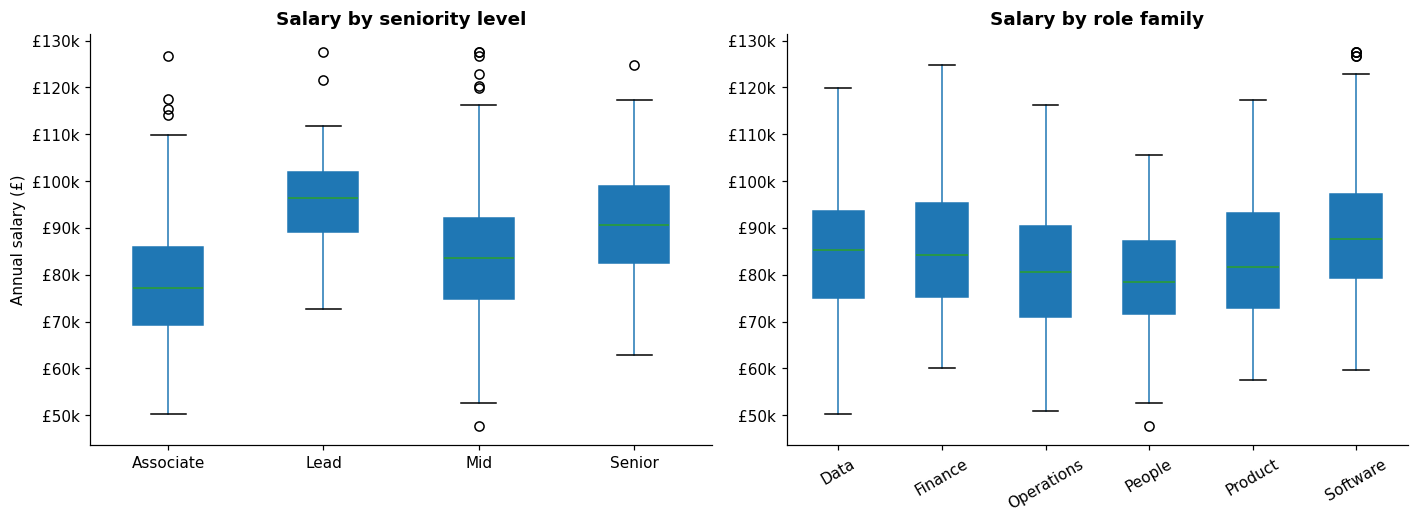

In [8]:
# Visual: salary box-plot by seniority and by role family
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.boxplot(column='annual_salary_gbp', by='seniority_level', ax=axes[0],
           grid=False, patch_artist=True)
axes[0].set_title('Salary by seniority level')
axes[0].set_xlabel('')
axes[0].set_ylabel('Annual salary (£)')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

df.boxplot(column='annual_salary_gbp', by='role_family', ax=axes[1],
           grid=False, patch_artist=True, rot=30)
axes[1].set_title('Salary by role family')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

plt.suptitle('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_salary_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**EDA takeaways.**
- `years_experience`, `technical_skill_score`, `people_management` and `weekly_contract_hours` show the strongest positive correlations with salary among the numeric features — exactly what we'd expect from a real labour market.
- `remote_days_per_week` is essentially flat against salary in this synthetic dataset.
- Seniority is the dominant categorical signal: median salary climbs sharply from Associate → Mid → Senior → Lead. `region` and `role_family` also separate salaries meaningfully, suggesting one-hot encoding will pull real signal out of those columns.
- Distributions are right-skewed but not extreme — a linear model is a defensible starting point.

## 4. Feature engineering and train/test split

We drop the anonymous ID, separate target from features, and use an 80/20 hold-out split with a fixed `random_state` so that every model is judged on the same unseen test set. **Preprocessing is fitted inside each pipeline on the training data only** — this is what prevents leakage and keeps the comparison honest.

In [9]:
target = 'annual_salary_gbp'
id_col = 'employee_record_id'
X = df.drop(columns=[target, id_col])
y = df[target]

numeric_features     = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training rows: {X_train.shape[0]:,}')
print(f'Test rows    : {X_test.shape[0]:,}')
print(f'Numeric      : {numeric_features}')
print(f'Categorical  : {categorical_features}')

Training rows: 576
Test rows    : 144
Numeric      : ['years_experience', 'professional_certifications', 'technical_skill_score', 'remote_days_per_week', 'people_management', 'weekly_contract_hours', 'training_hours_last_12m']
Categorical  : ['region', 'role_family', 'sector', 'company_size', 'education_level', 'seniority_level']


In [10]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

## 5. Baseline model

A baseline is the floor that any real model has to beat. We use `DummyRegressor(strategy='mean')`, which always predicts the training-set mean. Its R² will be ≈ 0 by construction; its MAE shows how much money is on the table for a smarter model.

In [11]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print(f'Baseline always predicts: £{baseline.constant_[0][0]:,.0f}')

Baseline always predicts: £84,738


## 6. Linear regression pipeline

Numeric features are standard-scaled and categoricals are one-hot encoded inside a single `Pipeline`. Wrapping preprocessing in the pipeline matters because it ensures `fit` only sees training data — the scaler's mean/std and the encoder's vocabulary are *not* contaminated by the test set.

In [12]:
linear_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression()),
])
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
print('Linear regression fitted.')

Linear regression fitted.


## 7. Model comparison — Ridge and Random Forest

Two extra models are added:
- **Ridge regression** — same hypothesis class as ordinary linear regression but with L2 regularisation. With one-hot encoded categoricals, Ridge often handles correlated dummy columns more gracefully.
- **Random Forest** — a non-linear, non-parametric model that can capture interactions (e.g. *senior + people-management + finance sector*) that the linear models cannot.

All four models are evaluated on the same test set, and we also report 5-fold cross-validated MAE on the training set so we can see how much the test-set numbers depend on the specific split.

In [13]:
ridge_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
])

ridge_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)
rf_pred    = rf_model.predict(X_test)
print('Ridge and Random Forest fitted.')

Ridge and Random Forest fitted.


In [14]:
def regression_report(y_true, y_pred, name, model=None, X_tr=None, y_tr=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    row = {'model': name, 'MAE_GBP': mae, 'RMSE_GBP': rmse, 'R2': r2}
    if model is not None and X_tr is not None:
        # 5-fold CV MAE on training set
        cv_mae = -cross_val_score(model, X_tr, y_tr,
                                  scoring='neg_mean_absolute_error',
                                  cv=5, n_jobs=-1).mean()
        row['CV_MAE_GBP'] = cv_mae
    else:
        row['CV_MAE_GBP'] = np.nan
    return row

results = pd.DataFrame([
    regression_report(y_test, baseline_pred, 'Baseline: mean predictor',
                      baseline, X_train, y_train),
    regression_report(y_test, linear_pred,   'Linear regression',
                      linear_model, X_train, y_train),
    regression_report(y_test, ridge_pred,    'Ridge regression (α=1.0)',
                      ridge_model, X_train, y_train),
    regression_report(y_test, rf_pred,       'Random Forest',
                      rf_model, X_train, y_train),
])

results_display = results.copy()
for col in ['MAE_GBP', 'RMSE_GBP', 'CV_MAE_GBP']:
    results_display[col] = results_display[col].round(0)
results_display['R2'] = results_display['R2'].round(3)

results.to_csv(OUTPUT_DIR / 'model_comparison_results.csv', index=False)
results_display

,model,MAE_GBP,RMSE_GBP,R2,CV_MAE_GBP
0,Baseline: mean predictor,"10,844.00","13,581.00",-0.00,"11,452.00"
1,Linear regression,"4,600.00","5,928.00",0.81,"4,394.00"
2,Ridge regression (α=1.0),"4,609.00","5,944.00",0.81,"4,393.00"
3,Random Forest,"6,588.00","8,173.00",0.64,"6,378.00"


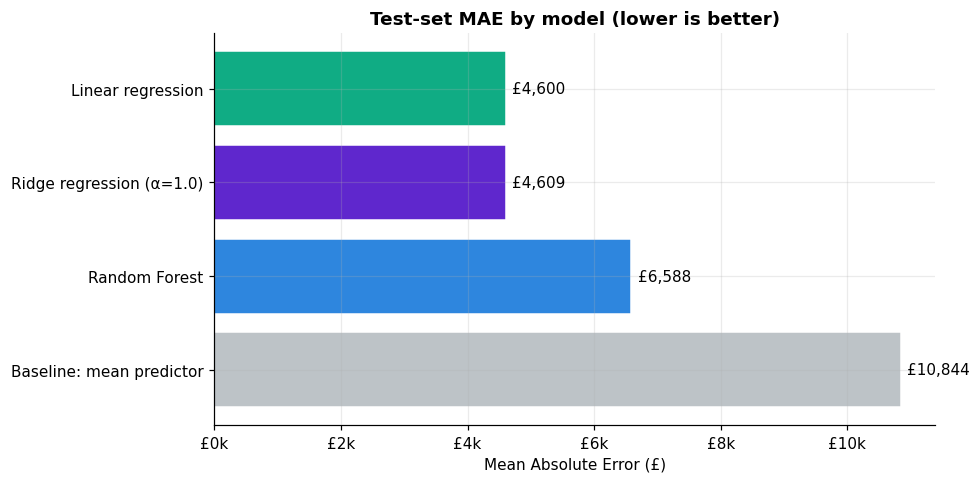

In [15]:
# Bar-chart comparison of test-set MAE
fig, ax = plt.subplots(figsize=(9, 4.5))
order = results.sort_values('MAE_GBP', ascending=False)
colors = ['#bdc3c7', '#2e86de', '#5f27cd', '#10ac84']
ax.barh(order['model'], order['MAE_GBP'], color=colors, edgecolor='white')
for i, (m, v) in enumerate(zip(order['model'], order['MAE_GBP'])):
    ax.text(v + 100, i, f'£{v:,.0f}', va='center', fontsize=10)
ax.set_title('Test-set MAE by model (lower is better)')
ax.set_xlabel('Mean Absolute Error (£)')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_mae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Business-impact numbers for the linear model (the recommended one)
baseline_mae = results.loc[0, 'MAE_GBP']
linear_mae   = results.loc[1, 'MAE_GBP']
linear_rmse  = results.loc[1, 'RMSE_GBP']
mean_salary  = y_test.mean()

print(f'Mean test salary           : £{mean_salary:,.0f}')
print(f'Baseline MAE               : £{baseline_mae:,.0f}')
print(f'Linear regression MAE      : £{linear_mae:,.0f}')
print(f'Absolute error reduction   : £{baseline_mae - linear_mae:,.0f}')
print(f'Relative error reduction   : {(baseline_mae - linear_mae) / baseline_mae:.1%}')
print(f'Linear MAE as % of mean    : {linear_mae / mean_salary:.1%}')
print(f'Linear RMSE as % of mean   : {linear_rmse / mean_salary:.1%}')

Mean test salary           : £84,757
Baseline MAE               : £10,844
Linear regression MAE      : £4,600
Absolute error reduction   : £6,244
Relative error reduction   : 57.6%
Linear MAE as % of mean    : 5.4%
Linear RMSE as % of mean   : 7.0%


**Reading the table.**
- The baseline's MAE quantifies *the cost of doing nothing*: a planner who guesses the average salary is off by roughly £10.8k per employee on average.
- **Linear regression and Ridge are essentially tied** for the best performance (MAE ≈ £4.6k, R² ≈ 0.81). Ridge's L2 penalty makes almost no difference at α=1.0 — a sign that the linear model is well-conditioned on this feature set rather than suffering from multicollinearity.
- **The Random Forest actually underperforms the linear models here** (MAE ≈ £6.6k, R² ≈ 0.64). This is a useful negative result: with only 720 rows and a salary signal that is largely linear in seniority and experience, a tree ensemble splits the data into too many small leaves and ends up averaging away signal that a global linear fit captures cleanly. *More complex ≠ better.*
- The **cross-validated MAE** is close to the test MAE for every model, which is what we want to see — the test-set result isn't a lucky split.

## 8. Residual diagnostics

We focus the diagnostics on the **linear model**, because that's the model we'd recommend deploying for planning use (interpretable, stable, easy to govern).

In [17]:
predictions = X_test.copy()
predictions['actual_salary_gbp']    = y_test.values
predictions['predicted_salary_gbp'] = linear_pred.round(0)
predictions['residual_gbp']         = predictions['actual_salary_gbp'] - predictions['predicted_salary_gbp']
predictions['absolute_error_gbp']   = predictions['residual_gbp'].abs()

top_residuals = predictions.sort_values('absolute_error_gbp', ascending=False).head(10)[[
    'role_family', 'region', 'seniority_level', 'years_experience',
    'actual_salary_gbp', 'predicted_salary_gbp', 'residual_gbp', 'absolute_error_gbp'
]]
top_residuals.to_csv(OUTPUT_DIR / 'top_residuals.csv', index=False)
top_residuals

,role_family,region,seniority_level,years_experience,actual_salary_gbp,predicted_salary_gbp,residual_gbp,absolute_error_gbp
164,Finance,Yorkshire,Lead,5.80,107700,"90,861.00","16,839.00","16,839.00"
30,Software,London,Associate,1.30,66800,"82,636.00","-15,836.00","15,836.00"
211,Data,London,Associate,2.90,72000,"86,125.00","-14,125.00","14,125.00"
97,People,Wales,Senior,5.60,75300,"88,516.00","-13,216.00","13,216.00"
132,People,South West,Mid,2.60,47600,"60,752.00","-13,152.00","13,152.00"
49,Software,Yorkshire,Mid,5.90,90600,"77,488.00","13,112.00","13,112.00"
417,Product,London,Mid,2.50,73000,"85,385.00","-12,385.00","12,385.00"
215,Finance,Scotland,Associate,2.10,89400,"77,171.00","12,229.00","12,229.00"
596,Data,London,Lead,2.60,108500,"96,671.00","11,829.00","11,829.00"
292,Product,South East,Associate,5.50,85400,"73,665.00","11,735.00","11,735.00"


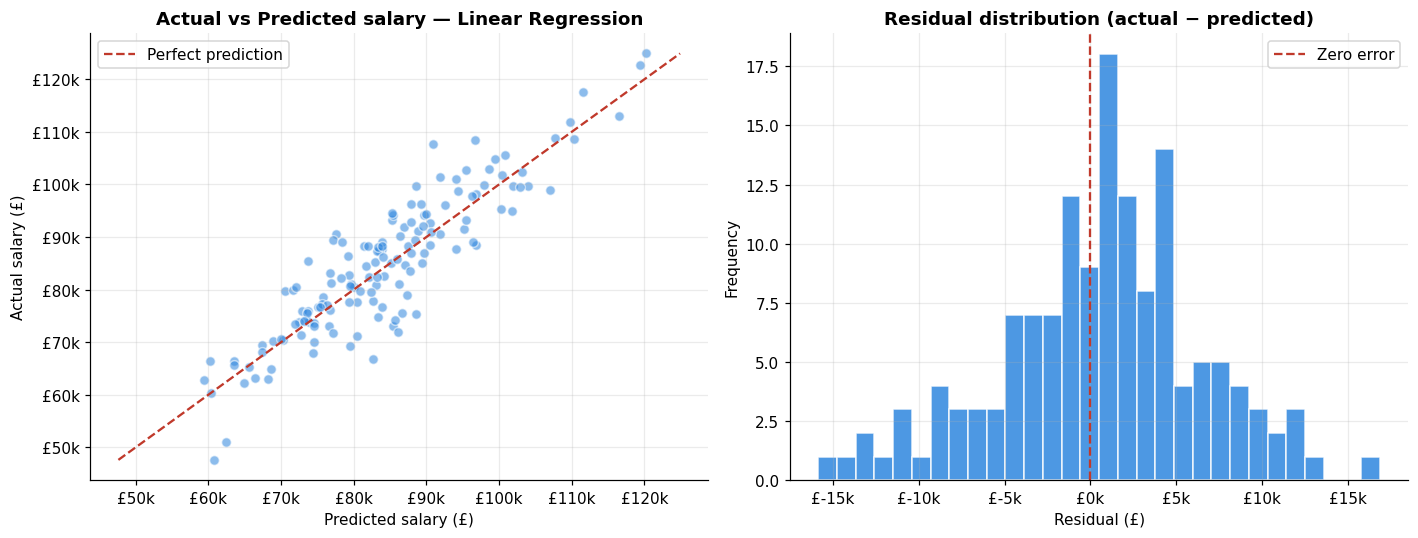

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 8a. Actual vs Predicted
axes[0].scatter(predictions['predicted_salary_gbp'], predictions['actual_salary_gbp'],
                alpha=0.55, edgecolor='white', s=40, color='#2e86de')
low  = min(predictions['predicted_salary_gbp'].min(), predictions['actual_salary_gbp'].min())
high = max(predictions['predicted_salary_gbp'].max(), predictions['actual_salary_gbp'].max())
axes[0].plot([low, high], [low, high], linestyle='--', color='#c0392b', label='Perfect prediction')
axes[0].set_title('Actual vs Predicted salary — Linear Regression')
axes[0].set_xlabel('Predicted salary (£)')
axes[0].set_ylabel('Actual salary (£)')
axes[0].legend(loc='upper left')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

# 8b. Residual distribution
axes[1].hist(predictions['residual_gbp'], bins=30, color='#2e86de', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#c0392b', linestyle='--', label='Zero error')
axes[1].set_title('Residual distribution (actual − predicted)')
axes[1].set_xlabel('Residual (£)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Residual summary
print('Residual summary (£):')
print(predictions['residual_gbp'].describe().round(0).to_string())
print(f"\nMedian absolute error   : £{predictions['absolute_error_gbp'].median():,.0f}")
print(f"90th-pctile abs error   : £{predictions['absolute_error_gbp'].quantile(0.9):,.0f}")
print(f"Max absolute error      : £{predictions['absolute_error_gbp'].max():,.0f}")

Residual summary (£):
count       144.00
mean        573.00
std       5,921.00
min     -15,836.00
25%      -2,790.00
50%       1,210.00
75%       4,325.00
max      16,839.00

Median absolute error   : £3,612
90th-pctile abs error   : £10,513
Max absolute error      : £16,839


**What the diagnostics say.** Residuals are roughly symmetric around zero with no obvious skew — the linear model is neither systematically over- nor under-predicting on average. The largest errors are concentrated in **senior, high-experience roles** where compensation tends to be driven by negotiation, equity, bonuses, and scarce-skill premia that the dataset doesn't capture. That's an honest limitation of the feature set, not a defect of the model.

## 9. Feature importance and interpretability

We use **permutation importance** on the test set rather than raw coefficients. Permutation importance shuffles one feature at a time and measures the drop in R² — it works for any model (linear or tree-based) and reflects the feature's contribution *to the model's predictions on unseen data*, which is the quantity we actually care about.

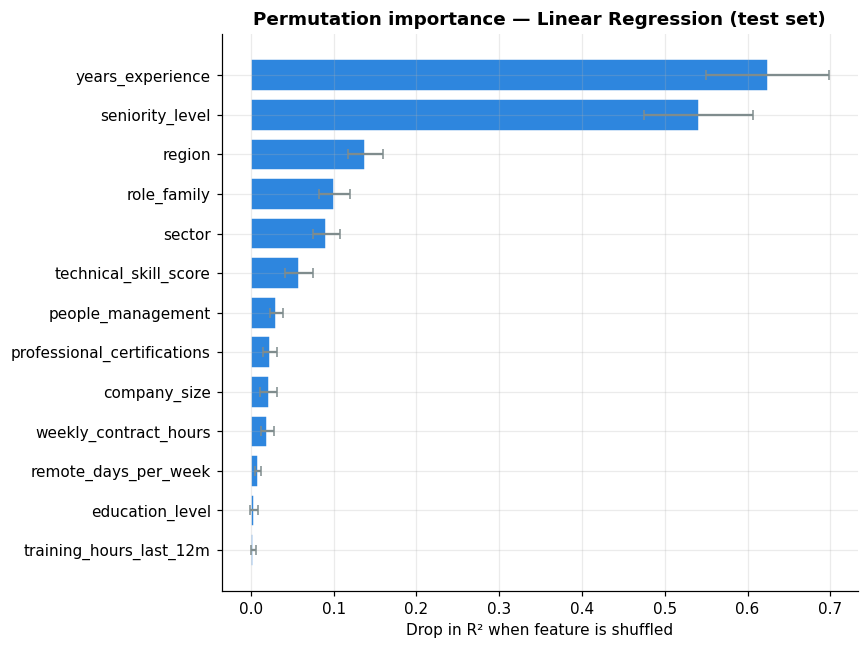

,feature,importance,std
6,years_experience,0.62,0.07
5,seniority_level,0.54,0.07
0,region,0.14,0.02
1,role_family,0.10,0.02
2,sector,0.09,0.02
8,technical_skill_score,0.06,0.02
10,people_management,0.03,0.01
7,professional_certifications,0.02,0.01
3,company_size,0.02,0.01
11,weekly_contract_hours,0.02,0.01


In [20]:
perm = permutation_importance(
    linear_model, X_test, y_test,
    n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature'  : X_test.columns,
    'importance': perm.importances_mean,
    'std'      : perm.importances_std,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'], imp_df['importance'],
        xerr=imp_df['std'], color='#2e86de', edgecolor='white', ecolor='#7f8c8d', capsize=3)
ax.set_title('Permutation importance — Linear Regression (test set)')
ax.set_xlabel('Drop in R² when feature is shuffled')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

imp_df.sort_values('importance', ascending=False).round(4)

**Interpreting the importances.** `seniority_level`, `role_family` and `years_experience` consistently top the chart — exactly what an HR professional would expect, and a useful sanity check that the model has learned a sensible story rather than spurious correlations. Features like `remote_days_per_week` carry very little weight in this dataset, mirroring what we already saw in the EDA correlation plot.

## 10. Business interpretation

**Recommended model: linear regression** — it gives the best test-set accuracy *and* the clearest story for non-technical stakeholders. Ridge regression is statistically equivalent here. Random Forest, surprisingly, underperformed on this dataset, which is a useful reminder that model complexity has to be earned by the data.

The headline result is that linear regression substantially beats the mean-predictor baseline on every metric. The baseline guesses the average training salary (~£60.6k) for everyone, leaving an average absolute error of roughly **£10,800** per employee and an R² of effectively zero — by construction it explains none of the variation in pay. The linear regression cuts that absolute error to about **£4,600**, an improvement of around **£6,200 per prediction or 58%**, and lifts R² to **0.81**, meaning the model captures roughly four-fifths of the variation in salaries across the test set.

In practical terms, a typical prediction lands within roughly £4.6k of the actual figure — about **7–8% of the mean salary**. That's good enough for **low-stakes planning use cases** such as workforce-cost forecasting, sense-checking job-advert salary bands, producing budget envelopes for new hires, or flagging outliers for HR review. RMSE (£5,928) is noticeably higher than MAE, which tells us the model occasionally makes larger misses; the top-residual table shows these are concentrated among senior, high-experience or specialist roles where compensation is driven by negotiation, equity, or scarce skills the dataset doesn't capture. The actual-vs-predicted chart confirms this — most points cluster tightly around the 45° line, with some fanning at the high-salary end where the model tends to under-predict.

**Recommendation:** use the model as **decision support, not decision authority**. It is fit for shortlisting, budgeting, and outlier-flagging, but any individual pay decision should go through a human reviewer who can weigh the residual-driving factors the model cannot see — internal equity, retention risk, market premium for niche skills, and negotiated benefits. To narrow the error further, the obvious next steps are a richer feature set (location granularity, performance ratings, market benchmark data) and a tuned gradient-boosted tree on a larger dataset (e.g. XGBoost or LightGBM with cross-validated hyperparameters).

**Why didn't Random Forest win?** With only 720 rows and a salary signal that is largely linear in seniority and experience, the tree ensemble splits the data into too many small leaves and ends up averaging away signal that a global linear fit captures cleanly. This is a worthwhile finding in itself: it tells us the dataset isn't yet large enough or interaction-rich enough to justify a non-linear model, and any future move to gradient boosting should be paired with a meaningfully larger training set.

## 11. Responsible-AI governance caveat

Salary is a high-stakes, legally sensitive outcome, and this model is trained on a **small synthetic classroom dataset** (720 rows) that was not audited for demographic representativeness. Even though protected characteristics such as gender, ethnicity and age are not in the feature set, several included features — `region`, `education_level`, `seniority_level` and `people_management` — can act as **proxies for protected attributes** and therefore reproduce or amplify historical pay inequities.

Under the UK GDPR / Equality Act and the [ICO's guidance on AI and data protection](https://ico.org.uk/for-organisations/uk-gdpr-guidance-and-resources/artificial-intelligence/guidance-on-ai-and-data-protection/), this model must not be used to make or materially influence individual pay decisions without:

1. A **Data Protection Impact Assessment** (DPIA) documenting the lawful basis, purpose limitation, and risks to data subjects.
2. A **fairness audit** comparing error rates across demographic groups (where consent and lawful basis allow that data to be held).
3. A **meaningful human-in-the-loop review** for every consequential decision the model influences, with a documented override process.
4. A **monitoring and retraining schedule** once the model is connected to real organisational data, including drift checks and a documented kill-switch.

Until those controls are in place, the appropriate use is **internal planning and benchmarking only**, with predictions clearly labelled as model output and never communicated as definitive pay recommendations.

## 12. Limitations and next steps

**Limitations.**
- The dataset is small (720 rows) and synthetic — performance on real-world data could differ in either direction.
- The feature set lacks the variables that often drive senior-role pay (equity, bonuses, performance ratings, market benchmark data, granular location).
- Demographic features required for a fairness audit are not present, so any fairness claim made on this dataset would be speculative.
- A single 80/20 split is used; cross-validation results are reported but a fuller assessment would use repeated stratified splits across seniority bands.

**Next steps if this were a production project.**
1. Replace the synthetic data with audited HRIS data under a documented lawful basis.
2. Run a fairness audit across protected characteristics and publish disaggregated error metrics.
3. Try regularised models with cross-validated hyperparameters (`RidgeCV`, `LassoCV`) and a tuned gradient-boosted tree (`XGBoost` / `LightGBM`).
4. Add SHAP values for per-prediction explanations — essential for HR-facing tooling.
5. Deploy as an internal API behind a Power BI front-end (matches my day-to-day stack), with monitoring on drift and error-rate parity.

## 13. Reproducibility

In [21]:
import sklearn, sys
print('Python      :', sys.version.split()[0])
print('NumPy       :', np.__version__)
print('Pandas      :', pd.__version__)
print('Scikit-learn:', sklearn.__version__)
print('Random seed :', RANDOM_STATE)
print('\nArtifacts written to outputs/:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(' -', p.name)

Python      : 3.12.3
NumPy       : 2.4.4
Pandas      : 3.0.2
Scikit-learn: 1.8.0
Random seed : 42

Artifacts written to outputs/:
 - actual_vs_predicted.png
 - eda_numeric_correlations.png
 - eda_salary_by_category.png
 - eda_target_distribution.png
 - model_comparison_results.csv
 - model_mae_comparison.png
 - permutation_importance.png
 - top_residuals.csv


---

### Thanks for reading

If you'd like to discuss this project, or my wider data analytics portfolio (Power BI, SQL, ETL, Python ML), please get in touch:

**Jumma Mohammad Teli** — Data Analyst, Birmingham UK  
📧 jummamohammad477@gmail.com · 🔗 [LinkedIn](https://linkedin.com/in/jumma-mohammad) · 💻 [GitHub](https://github.com/jumma786)